In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

Remider of the price_category map `category_map = {"Low": 0, "Medium": 1, "High": 2}`

In [2]:
# Load processed data
X_train = pd.read_csv('../data/processed/classification/X_train_clf.csv')
X_test = pd.read_csv('../data/processed/classification/X_test_clf.csv')
y_train = pd.read_csv('../data/processed/classification/y_train_clf.csv')
y_test = pd.read_csv('../data/processed/classification/y_test_clf.csv')

In [3]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [4]:
svm_linear = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="linear", C=1.0, random_state=42))
])

svm_rbf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

svm_linear.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

pred_linear = svm_linear.predict(X_test)
pred_rbf = svm_rbf.predict(X_test)

/Users/jonathan/Documents/MSc Data Sci/Year 1/Semester 2/Advanced ML/Exam/california_housing_prices_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/jonathan/Documents/MSc Data Sci/Year 1/Semester 2/Advanced ML/Exam/california_housing_prices_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## SVM Concepts
Margin maximization:
SVM searches for a decision boundary that maximizes the margin, meaning the distance between the boundary and the nearest points from each class.

Role of C:
C controls the trade-off between a wider margin and fewer misclassifications.
- Large C: prioritizes correct classification, smaller margin.
- Small C: allows more errors, wider margin.

Role of kernel functions:
Kernel functions transform data into a higher-dimensional space so that non-linear class separation becomes possible.
- Linear kernel: suitable when classes are approximately linearly separable.
- RBF kernel: suitable when class boundaries are non-linear.

## Evaluation of the Classifiers

In [14]:
def evaluate_classifier(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"\n{name}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Low", "Medium", "High"], zero_division=0))

In [7]:
evaluate_classifier(y_test, pred_linear, "Linear SVM")


Linear SVM
Accuracy:  0.7294
Precision: 0.7322
Recall:    0.7294
F1-score:  0.7306

Confusion Matrix:
[[1064  288   25]
 [ 224  887  264]
 [  50  266 1060]]

Classification Report:
              precision    recall  f1-score   support

         Low       0.80      0.77      0.78      1377
      Medium       0.62      0.65      0.63      1375
        High       0.79      0.77      0.78      1376

    accuracy                           0.73      4128
   macro avg       0.73      0.73      0.73      4128
weighted avg       0.73      0.73      0.73      4128



In [22]:
evaluate_classifier(y_test, pred_linear, "Linear SVM")


Linear SVM
Accuracy:  0.7294
Precision: 0.7322
Recall:    0.7294
F1-score:  0.7306

Classification Report:
              precision    recall  f1-score   support

         Low       0.80      0.77      0.78      1377
      Medium       0.62      0.65      0.63      1375
        High       0.79      0.77      0.78      1376

    accuracy                           0.73      4128
   macro avg       0.73      0.73      0.73      4128
weighted avg       0.73      0.73      0.73      4128



In [21]:
evaluate_classifier(y_test, pred_rbf, "RBF SVM")


RBF SVM
Accuracy:  0.7548
Precision: 0.7573
Recall:    0.7548
F1-score:  0.7557

Classification Report:
              precision    recall  f1-score   support

         Low       0.80      0.81      0.81      1377
      Medium       0.65      0.68      0.66      1375
        High       0.82      0.77      0.80      1376

    accuracy                           0.75      4128
   macro avg       0.76      0.75      0.76      4128
weighted avg       0.76      0.75      0.76      4128



The RBF SVM performs better than the Linear SVM on this task, achieving higher accuracy, precision, recall, and F1-score, so it is the stronger model overall for the three-class housing categorization problem.

##### Overall comparison
RBF SVM: Accuracy = 0.7548, F1-score = 0.7557.\
Linear SVM: Accuracy = 0.7294, F1-score = 0.7306.

The improvement is modest but consistent across the main metrics. This suggests the class boundaries are likely non-linear, so the RBF kernel is better able to separate the price groups than a straight linear boundary.

##### lass-level performance
For the RBF SVM, the model performs best on Low and High classes, with F1-scores of 0.81 and 0.80, respectively. The Medium class is the hardest to predict, with F1-score 0.66, which is common because middle categories often overlap with both extremes.

For the Linear SVM, the same pattern appears, but performance is weaker overall. The Medium class remains the most difficult, with F1-score 0.63, showing that the linear boundary cannot capture the middle-class separation as effectively.

##### Interpretation of errors
False positives occur when a district is predicted as a higher price category than it truly is. False negatives occur when a district is predicted as a lower price category than it actually belongs to. In housing classification, these errors matter because misclassifying a district as cheaper or more expensive can affect investment or policy decisions.

##### Model choice
Based on these results, the RBF SVM should be preferred for the classification task. It provides better overall predictive performance and handles the non-linear structure of the dataset more effectively than the linear model.

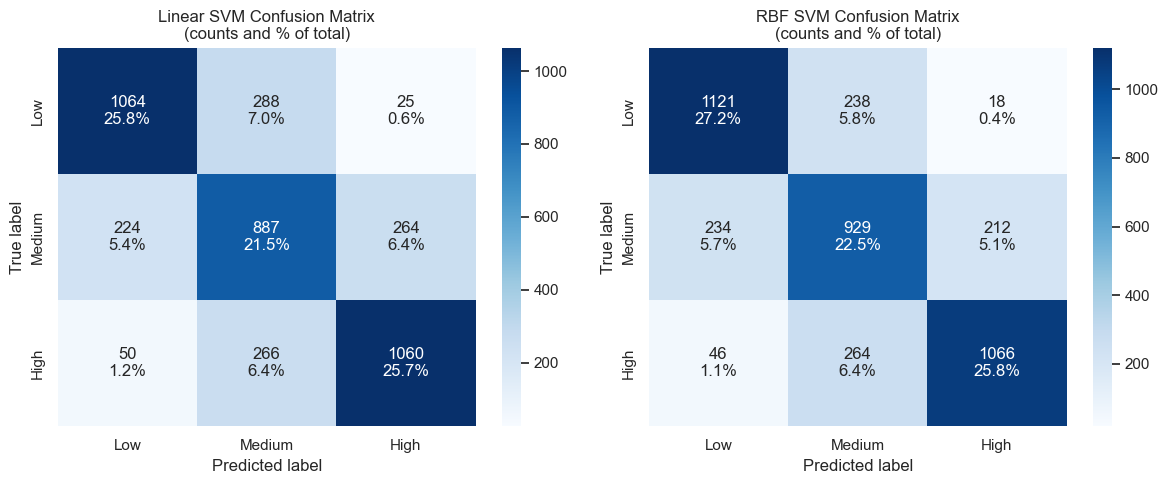

In [20]:
category_map = {"Low": 0, "Medium": 1, "High": 2}
inv_map = {v: k for k, v in category_map.items()} 

def to_numeric_labels(y, mapping):
    """Convert y (Series/array/list) of string labels to numeric using mapping.
       Raises ValueError if an unknown label is encountered."""
    if isinstance(y, pd.Series):
        mapped = y.map(mapping)
    else:
        y_arr = np.asarray(y)
        # If already numeric, return as int array
        if np.issubdtype(y_arr.dtype, np.number):
            return y_arr.astype(int)
        mapped = pd.Series([mapping.get(x, np.nan) for x in y_arr])
    if mapped.isnull().any():
        unknown = sorted(set(pd.Series(y).unique()) - set(mapping.keys()))
        raise ValueError(f"Found labels not in category_map: {unknown}")
    return mapped.astype(int).to_numpy()

# Convert labels
y_test_num = to_numeric_labels(y_test, category_map)
pred_linear_num = to_numeric_labels(pred_linear, category_map)
pred_rbf_num = to_numeric_labels(pred_rbf, category_map)

# Fixed numeric label order so matrices are comparable
labels_numeric = [0, 1, 2]
tick_labels = [inv_map[i] for i in labels_numeric]

# Compute confusion matrices
cm_linear = confusion_matrix(y_test_num, pred_linear_num, labels=labels_numeric)
cm_rbf = confusion_matrix(y_test_num, pred_rbf_num, labels=labels_numeric)

# Percent of total samples
denom = cm_linear.sum() 
cm_linear_perc = (cm_linear.astype(float) / denom) * 100
cm_rbf_perc = (cm_rbf.astype(float) / denom) * 100

# Build annotation arrays (count + percent of total)
def build_annot(cm_counts, cm_perc):
    annot = np.empty_like(cm_counts).astype(object)
    nrows, ncols = cm_counts.shape
    for i in range(nrows):
        for j in range(ncols):
            annot[i, j] = f"{cm_counts[i, j]}\n{cm_perc[i, j]:.1f}%"
    return annot

annot_linear = build_annot(cm_linear, cm_linear_perc)
annot_rbf = build_annot(cm_rbf, cm_rbf_perc)

# Plot side-by-side
plt.figure(figsize=(12, 5))
sns.set_theme(style="whitegrid")

ax1 = plt.subplot(1, 2, 1)
sns.heatmap(cm_linear, annot=annot_linear, fmt="", cmap="Blues",
            xticklabels=tick_labels, yticklabels=tick_labels, cbar=True, ax=ax1)
ax1.set_xlabel("Predicted label")
ax1.set_ylabel("True label")
ax1.set_title("Linear SVM Confusion Matrix\n(counts and % of total)")

ax2 = plt.subplot(1, 2, 2)
sns.heatmap(cm_rbf, annot=annot_rbf, fmt="", cmap="Blues",
            xticklabels=tick_labels, yticklabels=tick_labels, cbar=True, ax=ax2)
ax2.set_xlabel("Predicted label")
ax2.set_ylabel("True label")
ax2.set_title("RBF SVM Confusion Matrix\n(counts and % of total)")

plt.tight_layout()
plt.show()

## Interpretation of False Positives and False Negatives
False positives occur when a district is predicted as a higher-price class than it actually belongs to.
This means the model overestimates the market category. False negatives occur when a district is predicted as a lower-price class than it actually belongs to.
This means the model underestimates the market category. In housing classification, false negatives may be especially important if expensive districts are incorrectly labeled as cheaper ones, because that can affect investment or policy decisions.